# Classification Coursework: Appendix Cancer Prediction

## 1. Dataset Selection and UN SDG Alignment

### 1.1 Dataset Information

**Dataset Name:** Appendix Cancer Prediction Dataset

**Source:** Kaggle

**Created by:** Ankush Panday

**Date Created/Published:** 2025

**Access Method:** Downloaded from Google Drive

### 1.2 UN Sustainable Development Goal Alignment

**Selected SDG:** SDG 3 - Good Health and Well-being

**Specific Target:** Targeted Appendix cancer

**Justification:**
This dataset directly supports SDG 3 by enabling:
- Early detection of appendix cancer through predictive modeling
- Identification of key risk factors (BMI, cholesterol, lifestyle habits)
- Prevention strategies based on health metrics
- Reduction in cancer-related mortality through timely intervention


### Questions

This dataset can answer the following meaningful questions:

1. **Can we accurately predict appendix cancer risk based on patient health metrics and lifestyle factors?**


### 1.4 Dataset Features Description

The dataset contains the following attributes:

1. **Patient_ID:** Unique ID according to patient
2. **Age:** Patient age in years
3. **Gender:** Male, Female, or Other
4. **BMI:** Body Mass Index
5. **Blood_Pressure:** Blood pressure reading
6. **Cholesterol_Level:** Cholesterol measurement
7. **Smoking_Status:** Whether patient smokes or not
8. **Alcohol_Consumption:** Level of alcohol consumption
9. **Physical_Activity:** Level of physical activity
10. **Family_History:** Family history of cancer
11. **Chronic_Diseases:** Presence of chronic diseases
12. **Country:** Geographic location
13. **Treatment_Type:** Type of treatment received
14. **Survival_Years_After_Diagnosis:** Years survived after diagnosis
15. **Appendix_Cancer_Prediction:** Target variable (0 = No Cancer, 1 = Cancer)

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier



from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score, classification_report, f1_score, make_scorer, confusion_matrix, precision_score, recall_score


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 1. **Exploratory Data Analysis and Data Understanding**

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/appendix_cancer_prediction_dataset.csv')
df.head()



,Patient_ID,Country,Age,Gender,BMI,Smoking_Status,Alcohol_Consumption,Family_History_Cancer,Genetic_Mutations,Chronic_Diseases,...,Cholesterol_Level,White_Blood_Cell_Count,Red_Blood_Cell_Count,Platelet_Count,Tumor_Markers,Symptom_Severity,Diagnosis_Delay_Days,Treatment_Type,Survival_Years_After_Diagnosis,Appendix_Cancer_Prediction
0,PID_000001,China,67,Female,28.6,No,Low,Yes,No,Diabetes,...,228,8.1,4.4,361,Negative,Mild,691,Surgery,6.5,Yes
1,PID_000002,Saudi Arabia,83,Female,19.4,No,Low,No,No,Diabetes,...,186,9.7,6.2,235,Negative,Moderate,275,Chemotherapy,1.6,No
2,PID_000003,France,52,Female,17.2,No,Low,Yes,No,Diabetes,...,231,8.2,4.6,269,Negative,Moderate,668,Chemotherapy,0.7,No
3,PID_000004,Russia,71,Male,31.8,Yes,Low,No,No,NaN,...,151,6.8,6.0,193,Negative,Moderate,256,Radiation,2.1,No
4,PID_000005,USA,19,Female,17.7,No,Low,No,No,Hypertension,...,236,6.7,4.9,396,Negative,Mild,370,Radiation,0.5,No


In [ ]:
print(df.shape)
print(df.columns)
print(df.dtypes)

(260000, 25)
Index(['Patient_ID', 'Country', 'Age', 'Gender', 'BMI', 'Smoking_Status',
       'Alcohol_Consumption', 'Family_History_Cancer', 'Genetic_Mutations',
       'Chronic_Diseases', 'Physical_Activity_Level', 'Diet_Type',
       'Radiation_Exposure', 'Previous_Cancers', 'Blood_Pressure',
       'Cholesterol_Level', 'White_Blood_Cell_Count', 'Red_Blood_Cell_Count',
       'Platelet_Count', 'Tumor_Markers', 'Symptom_Severity',
       'Diagnosis_Delay_Days', 'Treatment_Type',
       'Survival_Years_After_Diagnosis', 'Appendix_Cancer_Prediction'],
      dtype='object')
Patient_ID                         object
Country                            object
Age                                 int64
Gender                             object
BMI                               float64
Smoking_Status                     object
Alcohol_Consumption                object
Family_History_Cancer              object
Genetic_Mutations                  object
Chronic_Diseases                   object


**Checking Null values and cleaning the data**

In [ ]:
df.isna().sum()

,0
Patient_ID,0
Country,0
Age,0
Gender,0
BMI,0
Smoking_Status,0
Alcohol_Consumption,0
Family_History_Cancer,0
Genetic_Mutations,0
Chronic_Diseases,130087


In [ ]:
df = df.drop(columns=['Patient_ID', 'Country', 'Treatment_Type', 'Survival_Years_After_Diagnosis', 'Diagnosis_Delay_Days'], errors='ignore')
df.isnull().sum()

,0
Age,0
Gender,0
BMI,0
Smoking_Status,0
Alcohol_Consumption,0
Family_History_Cancer,0
Genetic_Mutations,0
Chronic_Diseases,130087
Physical_Activity_Level,0
Diet_Type,0


In [ ]:
print("Special character counts:\n")
print((df == "–").sum())

Special character counts:

Age                           0
Gender                        0
BMI                           0
Smoking_Status                0
Alcohol_Consumption           0
Family_History_Cancer         0
Genetic_Mutations             0
Chronic_Diseases              0
Physical_Activity_Level       0
Diet_Type                     0
Radiation_Exposure            0
Previous_Cancers              0
Blood_Pressure                0
Cholesterol_Level             0
White_Blood_Cell_Count        0
Red_Blood_Cell_Count          0
Platelet_Count                0
Tumor_Markers                 0
Symptom_Severity              0
Appendix_Cancer_Prediction    0
dtype: int64


In [ ]:
print("Number of duplicate rows:\n")
print(df.duplicated().sum())

Number of duplicate rows:

0


In [ ]:
#dropping duplicatied rows if any
df = df.dropna()

In [ ]:
#since only chronic diseases had null values so handling that
df['Chronic_Diseases'] = df['Chronic_Diseases'].fillna('None')
df.isnull().sum()

,0
Age,0
Gender,0
BMI,0
Smoking_Status,0
Alcohol_Consumption,0
Family_History_Cancer,0
Genetic_Mutations,0
Chronic_Diseases,0
Physical_Activity_Level,0
Diet_Type,0


In [ ]:
df.head(5)




,Age,Gender,BMI,Smoking_Status,Alcohol_Consumption,Family_History_Cancer,Genetic_Mutations,Chronic_Diseases,Physical_Activity_Level,Diet_Type,Radiation_Exposure,Previous_Cancers,Blood_Pressure,Cholesterol_Level,White_Blood_Cell_Count,Red_Blood_Cell_Count,Platelet_Count,Tumor_Markers,Symptom_Severity,Appendix_Cancer_Prediction
0,67,Female,28.6,No,Low,Yes,No,Diabetes,High,Non-Vegetarian,No,No,156,228,8.1,4.4,361,Negative,Mild,Yes
1,83,Female,19.4,No,Low,No,No,Diabetes,Low,Non-Vegetarian,No,No,117,186,9.7,6.2,235,Negative,Moderate,No
2,52,Female,17.2,No,Low,Yes,No,Diabetes,Low,Non-Vegetarian,No,No,115,231,8.2,4.6,269,Negative,Moderate,No
4,19,Female,17.7,No,Low,No,No,Hypertension,Moderate,Non-Vegetarian,No,No,179,236,6.7,4.9,396,Negative,Mild,No
5,44,Male,21.2,No,Low,No,Yes,Hypertension,Low,Vegetarian,No,No,113,270,6.9,4.9,397,Negative,Mild,No


In [ ]:

print(df['Gender'].unique())
print(df['Alcohol_Consumption'].unique())
print(df['Chronic_Diseases'].unique())
print(df['Family_History_Cancer'].unique())
print(df['Genetic_Mutations'].unique())
print(df['Physical_Activity_Level'].unique())
print(df['Tumor_Markers'].unique())
print(df['Symptom_Severity'].unique())
print(df['Diet_Type'].unique())
print(df['Smoking_Status'].unique())
print(df['Radiation_Exposure'].unique())
print(df['Previous_Cancers'].unique())
print(df['Appendix_Cancer_Prediction'].unique())





['Female' 'Male' 'Other']
['Low' 'High' 'Moderate']
['Diabetes' 'Hypertension']
['Yes' 'No']
['No' 'Yes']
['High' 'Low' 'Moderate']
['Negative' 'Positive']
['Mild' 'Moderate' 'Severe']
['Non-Vegetarian' 'Vegetarian' 'Vegan']
['No' 'Yes']
['No' 'Yes']
['No' 'Yes']
['Yes' 'No']


In [ ]:
#encoding the text into number

df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1, 'Other': 2})
df['Alcohol_Consumption'] = df['Alcohol_Consumption'].map({'Low': 0, 'Moderate': 1, 'High': 2})
df['Chronic_Diseases'] = df['Chronic_Diseases'].map({'None': 0, 'Diabetes': 1, 'Hypertension': 2})
df['Family_History_Cancer'] = df['Family_History_Cancer'].map({'No': 0, 'Yes': 1})
df['Genetic_Mutations'] = df['Genetic_Mutations'].map({'No': 0, 'Yes': 1})
df['Physical_Activity_Level'] = df['Physical_Activity_Level'].map({'Low': 0, 'Moderate': 1, 'High': 2})
df['Tumor_Markers'] = df['Tumor_Markers'].map({'Negative': 0, 'Positive': 1})
df['Symptom_Severity'] = df['Symptom_Severity'].map({'Mild': 0, 'Moderate': 1, 'Severe': 2})
df['Diet_Type'] = df['Diet_Type'].map({'Non-Vegetarian': 0, 'Vegetarian': 1, 'Vegan': 2})
df['Radiation_Exposure'] = df['Radiation_Exposure'].map({'Yes': 0, 'No': 1})
df['Previous_Cancers'] = df['Previous_Cancers'].map({'Yes': 0, 'No': 1})
df['Appendix_Cancer_Prediction'] = df['Appendix_Cancer_Prediction'].map({'Yes': 0, 'No': 1})
df['Smoking_Status'] = df['Smoking_Status'].map({'Yes': 0, 'No': 1})




In [ ]:
df.dtypes
df.head(5)

,Age,Gender,BMI,Smoking_Status,Alcohol_Consumption,Family_History_Cancer,Genetic_Mutations,Chronic_Diseases,Physical_Activity_Level,Diet_Type,Radiation_Exposure,Previous_Cancers,Blood_Pressure,Cholesterol_Level,White_Blood_Cell_Count,Red_Blood_Cell_Count,Platelet_Count,Tumor_Markers,Symptom_Severity,Appendix_Cancer_Prediction
0,67,1,28.6,1,0,1,0,1,2,0,1,1,156,228,8.1,4.4,361,0,0,0
1,83,1,19.4,1,0,0,0,1,0,0,1,1,117,186,9.7,6.2,235,0,1,1
2,52,1,17.2,1,0,1,0,1,0,0,1,1,115,231,8.2,4.6,269,0,1,1
4,19,1,17.7,1,0,0,0,2,1,0,1,1,179,236,6.7,4.9,396,0,0,1
5,44,0,21.2,1,0,0,1,2,0,1,1,1,113,270,6.9,4.9,397,0,0,1


In [ ]:
#Computing summary statistics
numerical_summary = df.describe()
print(f"Numerical Summary: /n {numerical_summary}")

Numerical Summary: /n                  Age         Gender            BMI  Smoking_Status  \
count  129913.000000  129913.000000  129913.000000   129913.000000   
mean       53.444813       0.531694      25.002319        0.701231   
std        20.723295       0.539068       4.979381        0.457720   
min        18.000000       0.000000       4.900000        0.000000   
25%        36.000000       0.000000      21.600000        0.000000   
50%        53.000000       1.000000      25.000000        1.000000   
75%        71.000000       1.000000      28.400000        1.000000   
max        89.000000       2.000000      45.100000        1.000000   

       Alcohol_Consumption  Family_History_Cancer  Genetic_Mutations  \
count        129913.000000          129913.000000      129913.000000   
mean              0.601618               0.203005           0.100221   
std               0.665315               0.402238           0.300295   
min               0.000000               0.000000          

**Visualizing Graph**

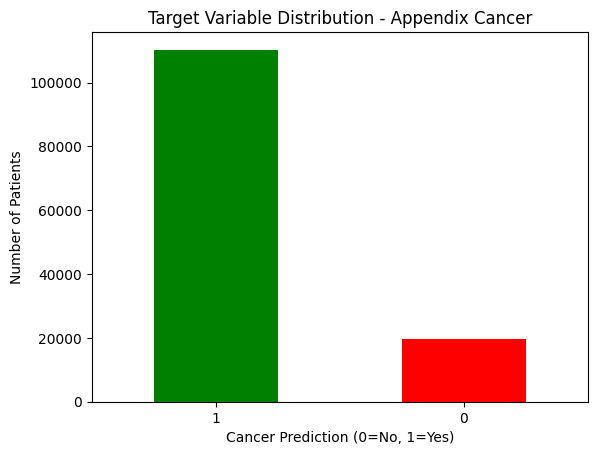

Class Distribution
Negative (No Cancer):19639
Positive (Cancer):110274

Imbalance Ratio: 0.18


In [ ]:
# Target Variable Distribution
plt.figure()
df['Appendix_Cancer_Prediction'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('Target Variable Distribution - Appendix Cancer')
plt.xlabel('Cancer Prediction (0=No, 1=Yes)')
plt.ylabel('Number of Patients')
plt.xticks(rotation=0)
plt.show()

# counts
counts = df['Appendix_Cancer_Prediction'].value_counts()

print("Class Distribution")
print(f"Negative (No Cancer):{counts[0]}")
print(f"Positive (Cancer):{counts[1]}")

# imbalance ratio
imbalance_ratio = counts[0] / counts[1]
print(f"\nImbalance Ratio: {imbalance_ratio:.2f}")


# **2. Build a Neural Network Model**

In [ ]:
# separating the data into features (x) and target (y)

x = df.drop(columns=['Appendix_Cancer_Prediction'])
y = df['Appendix_Cancer_Prediction']

In [ ]:
#spliting the data into training and testing sets
#80% to train the model and 20% to test
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


feature_names = x_train.columns



In [ ]:
# scaling the data
# preventing the model from getting confused by big numbers by making the numbers similar in size

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [ ]:
#building the neural network
modelmlp = MLPClassifier(hidden_layer_sizes=(64, 32), solver='adam', activation='logistic', max_iter=300, random_state=42)


In [ ]:
# training the model
# the model looks at x_train and learns to match it to y_train
modelmlp.fit(x_train, y_train)

MLPClassifier(activation='logistic', hidden_layer_sizes=(64, 32), max_iter=300,
              random_state=42)

In [ ]:
#evaluating the model on both sets
#checking both training and testing performance as per instructions.
mlp_train_pred = modelmlp.predict(x_train)
mlp_test_pred = modelmlp.predict(x_test)

#checking how well model performs on the data
print("MLP – Training")
print(classification_report(y_train, mlp_train_pred))

print("MLP – Test")
print(classification_report(y_test, mlp_test_pred))

MLP – Training
              precision    recall  f1-score   support

           0       0.00      0.00      0.00     15689
           1       0.85      1.00      0.92     88241

    accuracy                           0.85    103930
   macro avg       0.42      0.50      0.46    103930
weighted avg       0.72      0.85      0.78    103930

MLP – Test
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      3950
           1       0.85      1.00      0.92     22033

    accuracy                           0.85     25983
   macro avg       0.42      0.50      0.46     25983
weighted avg       0.72      0.85      0.78     25983



# **3. Build a Primary Model**

**building the machine learning model**
**Logistic Rregression**

In [ ]:
#building the machine learning models
#logistic regression
modelLr = LogisticRegression(class_weight='balanced', max_iter=10000)



In [ ]:
#fitting the model to the training data
modelLr.fit(x_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=10000)

In [ ]:
lr_train_pred = modelLr.predict(x_train)
lr_test_pred = modelLr.predict(x_test)

print("Logistic Regression – Training")
print(classification_report(y_train, lr_train_pred))

print("Logistic Regression – Test")
print(classification_report(y_test, lr_test_pred))

Logistic Regression – Training
              precision    recall  f1-score   support

           0       0.16      0.51      0.24     15689
           1       0.85      0.51      0.64     88241

    accuracy                           0.51    103930
   macro avg       0.50      0.51      0.44    103930
weighted avg       0.75      0.51      0.58    103930

Logistic Regression – Test
              precision    recall  f1-score   support

           0       0.15      0.49      0.23      3950
           1       0.85      0.50      0.63     22033

    accuracy                           0.50     25983
   macro avg       0.50      0.50      0.43     25983
weighted avg       0.74      0.50      0.57     25983



In [ ]:
print(" Logistic Regression Evaluation")
print(classification_report(y_test, lr_test_pred))


 Logistic Regression Evaluation
              precision    recall  f1-score   support

           0       0.15      0.49      0.23      3950
           1       0.85      0.50      0.63     22033

    accuracy                           0.50     25983
   macro avg       0.50      0.50      0.43     25983
weighted avg       0.74      0.50      0.57     25983



**Building the machine learning models Decision Tree**

In [ ]:
#decision tree
dec_tree = DecisionTreeClassifier(max_depth=25, class_weight='balanced')


In [ ]:
#fitting the model to the training data
dec_tree.fit(x_train, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=25)

In [ ]:
# Decision Tree predictions
dt_train_pred = dec_tree.predict(x_train)
dt_test_pred = dec_tree.predict(x_test)

# Evaluate
print("Decision Tree – Training")
print(classification_report(y_train, dt_train_pred))

print("Decision Tree – Test")
print(classification_report(y_test, dt_test_pred))


Decision Tree – Training
              precision    recall  f1-score   support

           0       0.44      0.91      0.59     15689
           1       0.98      0.79      0.88     88241

    accuracy                           0.81    103930
   macro avg       0.71      0.85      0.73    103930
weighted avg       0.90      0.81      0.83    103930

Decision Tree – Test
              precision    recall  f1-score   support

           0       0.15      0.32      0.21      3950
           1       0.85      0.68      0.76     22033

    accuracy                           0.63     25983
   macro avg       0.50      0.50      0.48     25983
weighted avg       0.74      0.63      0.67     25983



In [ ]:
print("\n Decision Tree Evaluation (balanced)")
print(classification_report(y_test, dt_test_pred))


 Decision Tree Evaluation (balanced)
              precision    recall  f1-score   support

           0       0.15      0.32      0.21      3950
           1       0.85      0.68      0.76     22033

    accuracy                           0.63     25983
   macro avg       0.50      0.50      0.48     25983
weighted avg       0.74      0.63      0.67     25983



# **3. Hyperparameter Tuning with Cross-Validation**



In [ ]:
#log regression
f1_scorer = make_scorer(f1_score)
lr_params = {
    'C': [0.01, 0.1, 1, 10]
}

grid_logisticReg = GridSearchCV(
    LogisticRegression(class_weight='balanced', max_iter=1000),
    lr_params,
    cv=5,
    scoring=f1_scorer
)

grid_logisticReg.fit(x_train, y_train)
modelLr = grid_logisticReg.best_estimator_

print("Best LR parameters:", grid_logisticReg.best_params_)
print("Best LR CV score:", grid_logisticReg.best_score_)


Best LR parameters: {'C': 0.1}
Best LR CV score: 0.6349674229831479


In [ ]:
dt_params = {
    'max_depth': [3, 5, 7, 10],
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(class_weight='balanced', random_state=42),
    dt_params,
    cv=5,
    scoring=f1_scorer
)

grid_dt.fit(x_train, y_train)

print("Decision Tree best parameters:", grid_dt.best_params_)
print("Decision Tree best cross-validation score:", grid_dt.best_score_)


Decision Tree best parameters: {'max_depth': 10}
Decision Tree best cross-validation score: 0.567078069075533


# **4. Feature Selection**

In [ ]:
#embedded feature selection method
# Logistic Regression feature importance
modelLr_importance = abs(pd.Series(modelLr.coef_[0], index=feature_names))
print("Logistic Regression feature importance:")
print(modelLr_importance)

# Decision Tree feature importance
dec_tree_importance = pd.Series(dec_tree.feature_importances_, index=feature_names)
print("\nDecision Tree feature importance:")
print(dec_tree_importance)


Logistic Regression feature importance:
Age                        0.009473
Gender                     0.006335
BMI                        0.003678
Smoking_Status             0.001750
Alcohol_Consumption        0.015364
Family_History_Cancer      0.006480
Genetic_Mutations          0.003031
Chronic_Diseases           0.000194
Physical_Activity_Level    0.001174
Diet_Type                  0.012672
Radiation_Exposure         0.001802
Previous_Cancers           0.002345
Blood_Pressure             0.007117
Cholesterol_Level          0.007135
White_Blood_Cell_Count     0.003987
Red_Blood_Cell_Count       0.007101
Platelet_Count             0.017480
Tumor_Markers              0.004243
Symptom_Severity           0.015379
dtype: float64

Decision Tree feature importance:
Age                        0.113390
Gender                     0.017462
BMI                        0.131710
Smoking_Status             0.013419
Alcohol_Consumption        0.025350
Family_History_Cancer      0.013597
Genetic_Mu

In [ ]:
print("\nLogistic Regression top 8 feature:")
top_8_features_lr = modelLr_importance.sort_values(ascending=False).head(8)
print(top_8_features_lr)

top_8_features_dt = dec_tree_importance.sort_values(ascending=False).head(8)
print("\nDecision Tree top 8 feature:")
print(top_8_features_dt)


Logistic Regression top 8 feature:
Platelet_Count          0.017480
Symptom_Severity        0.015379
Alcohol_Consumption     0.015364
Diet_Type               0.012672
Age                     0.009473
Cholesterol_Level       0.007135
Blood_Pressure          0.007117
Red_Blood_Cell_Count    0.007101
dtype: float64

Decision Tree top 8 feature:
Cholesterol_Level         0.131910
BMI                       0.131710
White_Blood_Cell_Count    0.119477
Platelet_Count            0.119291
Age                       0.113390
Blood_Pressure            0.109541
Red_Blood_Cell_Count      0.083625
Alcohol_Consumption       0.025350
dtype: float64


In [ ]:
# Features (only top 8) and target
lr_top_features = top_8_features_lr.index.tolist()
dt_top_features = top_8_features_dt.index.tolist()

X_lr = df[lr_top_features].copy()
X_dt = df[dt_top_features].copy()
y = df['Appendix_Cancer_Prediction']

x_train_lr, x_test_lr, y_train_lr, y_test_lr = train_test_split(X_lr, y, test_size=0.2, random_state=42)
x_train_dt, x_test_dt, y_train_dt, y_test_dt = train_test_split(X_dt, y, test_size=0.2, random_state=42)



In [ ]:
#scaling that data
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# **6. Final Models and Comparative Analysis**

In [ ]:
# Logistic Regression
final_lr = LogisticRegression(class_weight='balanced',max_iter=1000)

# Decision Tree
final_dt = DecisionTreeClassifier(max_depth=10, class_weight='balanced')

In [ ]:
# Train Logistic Regression
final_lr.fit(x_train_lr, y_train_lr)


LogisticRegression(class_weight='balanced', max_iter=1000)

In [ ]:
# Train Decision Tree
final_dt.fit(x_train_dt, y_train_dt)

DecisionTreeClassifier(class_weight='balanced', max_depth=10)

In [ ]:
# Logistic Regression predictions
y_pred_lr = final_lr.predict(x_test_lr)

# Decision Tree predictions
y_pred_dt = final_dt.predict(x_test_dt)

In [ ]:
# Logistic Regression
print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test_lr, y_pred_lr))
print("Confusion Matrix:\n", confusion_matrix(y_test_lr, y_pred_lr))
print(classification_report(y_test_lr, y_pred_lr))

# Decision Tree
print("\nDecision Tree")
print("Accuracy:", accuracy_score(y_test_dt, y_pred_dt))
print("Confusion Matrix:\n", confusion_matrix(y_test_dt, y_pred_dt))
print(classification_report(y_test_dt, y_pred_dt))

Logistic Regression
Accuracy: 0.5017896316822538
Confusion Matrix:
 [[ 1968  1982]
 [10963 11070]]
              precision    recall  f1-score   support

           0       0.15      0.50      0.23      3950
           1       0.85      0.50      0.63     22033

    accuracy                           0.50     25983
   macro avg       0.50      0.50      0.43     25983
weighted avg       0.74      0.50      0.57     25983


Decision Tree
Accuracy: 0.4160027710426048
Confusion Matrix:
 [[ 2500  1450]
 [13724  8309]]
              precision    recall  f1-score   support

           0       0.15      0.63      0.25      3950
           1       0.85      0.38      0.52     22033

    accuracy                           0.42     25983
   macro avg       0.50      0.51      0.39     25983
weighted avg       0.75      0.42      0.48     25983



# **Comparative Analysis**

In [ ]:

print("Compariosn of final classficiation model")


# Logistic Regression metrics
lr_acc = accuracy_score(y_test_lr, y_pred_lr)
lr_prec = precision_score(y_test_lr, y_pred_lr)
lr_rec = recall_score(y_test_lr, y_pred_lr)
lr_f1 = f1_score(y_test_lr, y_pred_lr)
lr_cv = grid_logisticReg.best_score_

# Decision Tree metrics
dt_acc = accuracy_score(y_test_dt, y_pred_dt)
dt_prec = precision_score(y_test_dt, y_pred_dt)
dt_rec = recall_score(y_test_dt, y_pred_dt)
dt_f1 = f1_score(y_test_dt, y_pred_dt)
dt_cv = grid_dt.best_score_

# Print simple table
print("\nLogistic Regression:")
print("Features: 8")
print(f"CV Score: {lr_cv}:.2f")
print("Accuracy:", lr_acc)
print("Precision:",lr_prec)
print("Recall:", lr_rec)
print("F1-Score:", lr_f1)

print("\nDecision Tree:")
print("Features: 8")
print("CV Score:", dt_cv)
print("Accuracy:", dt_acc)
print("Precision:", dt_prec)
print("Recall:", dt_rec)
print("F1-Score:", dt_f1)


# Best model
if lr_f1 > dt_f1:
    print("\nBest Model: Logistic Regression")
else:
    print("\nBest Model: Decision Tree")

Compariosn of final classficiation model

Logistic Regression:
Features: 8
CV Score: 0.6349674229831479:.2f
Accuracy: 0.5017896316822538
Precision: 0.8481458780263561
Recall: 0.5024281759179413
F1-Score: 0.6310389055151774

Decision Tree:
Features: 8
CV Score: 0.567078069075533
Accuracy: 0.4160027710426048
Precision: 0.8514192027871709
Recall: 0.3771161439658694
F1-Score: 0.5227101157523906

Best Model: Logistic Regression
